In [1]:
import pandas as pd
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("GALAXY_DATASET/final_15000.csv")
df.head()

,dr7objid,asset_id,t01_smooth_or_features_a01_smooth_debiased,t01_smooth_or_features_a02_features_or_disk_debiased,t02_edgeon_a04_yes_debiased,t03_bar_a06_bar_debiased,t04_spiral_a08_spiral_debiased,t08_odd_feature_a24_merger_debiased,t08_odd_feature_a22_irregular_debiased
0,587722981742018657,15,0.003,0.955,0.000000,0.000000,0.733360,0.003648,0.526693
1,587722981744050315,35,0.000,0.981,0.000289,0.402361,0.998695,0.000000,0.045512
2,587722981746016481,63,0.020,0.973,0.000000,0.216366,0.995563,0.000000,0.437910
3,587722981747654761,81,0.766,0.757,0.108623,0.381713,0.926622,0.000000,0.889990
4,587722981747982465,89,0.154,0.846,0.003660,0.885386,0.839584,0.211087,0.340519


In [3]:
# 10 images are missing from the folder, drop those rows
img_folder = "GALAXY_DATASET/Images Differing sizes/224"
valid = set(int(f.replace(".jpg", "")) for f in os.listdir(img_folder) if f.endswith(".jpg"))
df = df[df["asset_id"].isin(valid)].reset_index(drop=True)
print(len(df))  # should be 14990

4048


In [4]:
def make_label(row, thresh=0.6):

    smooth    = row["t01_smooth_or_features_a01_smooth_debiased"]
    featured  = row["t01_smooth_or_features_a02_features_or_disk_debiased"]

    irregular=row["t08_odd_feature_a22_irregular_debiased"]
    bar       = row["t03_bar_a06_bar_debiased"]
    spiral    = row["t04_spiral_a08_spiral_debiased"]
    edgeon    = row["t02_edgeon_a04_yes_debiased"]
    merger = row["t08_odd_feature_a24_merger_debiased"]
   

    if merger>thresh:
        return "merger"
    elif edgeon>thresh:
        return "edge_on"
    elif irregular>thresh:
        return "irregular"
    elif bar>thresh:
        return "barred_spiral"
    elif spiral>thresh:
        return "spiral"
    elif smooth>thresh:
        return "smooth"
    else:
        return "featured"
    

df["label"] = df.apply(make_label, axis=1)
df = df.dropna(subset=["label"]).reset_index(drop=True)
print(df["label"].value_counts())

label
spiral           1260
smooth            964
barred_spiral     702
featured          521
edge_on           365
irregular         165
merger             71
Name: count, dtype: int64


In [5]:
classes = sorted(df["label"].dropna().unique())

print(classes)
print(f"Number of classes: {len(classes)}")

class_to_idx = {c:i for i, c in enumerate(classes)}
idx_to_class = {i:c for c, i in class_to_idx.items()}
df["label_idx"] = df["label"].map(class_to_idx)

['barred_spiral', 'edge_on', 'featured', 'irregular', 'merger', 'smooth', 'spiral']
Number of classes: 7


In [6]:
class GalaxyDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        path = os.path.join(self.img_dir, f"{int(row['asset_id'])}.jpg")
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(row["label_idx"])

In [7]:

label_counts = df["label"].value_counts()
df = df[df["label"].isin(label_counts[label_counts >= 200].index)].reset_index(drop=True)
print(df["label"].value_counts())
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])
print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")


label
spiral           1260
smooth            964
barred_spiral     702
featured          521
edge_on           365
Name: count, dtype: int64
train: 2668  val: 572  test: 572


In [8]:
# imagenet mean/std since we're using pretrained models
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(360),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [9]:
train_ds = GalaxyDataset(train_df, img_folder, transform=train_tfms)
val_ds   = GalaxyDataset(val_df,   img_folder, transform=val_tfms)
test_ds  = GalaxyDataset(test_df,  img_folder, transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=1)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=1)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=1)

print(f"batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

batches — train: 84  val: 18  test: 18


['dr7objid', 'asset_id', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a02_features_or_disk_debiased', 't02_edgeon_a04_yes_debiased', 't03_bar_a06_bar_debiased', 't04_spiral_a08_spiral_debiased', 't08_odd_feature_a24_merger_debiased', 't08_odd_feature_a22_irregular_debiased', 'label', 'label_idx']
torch.Size([32, 3, 224, 224])


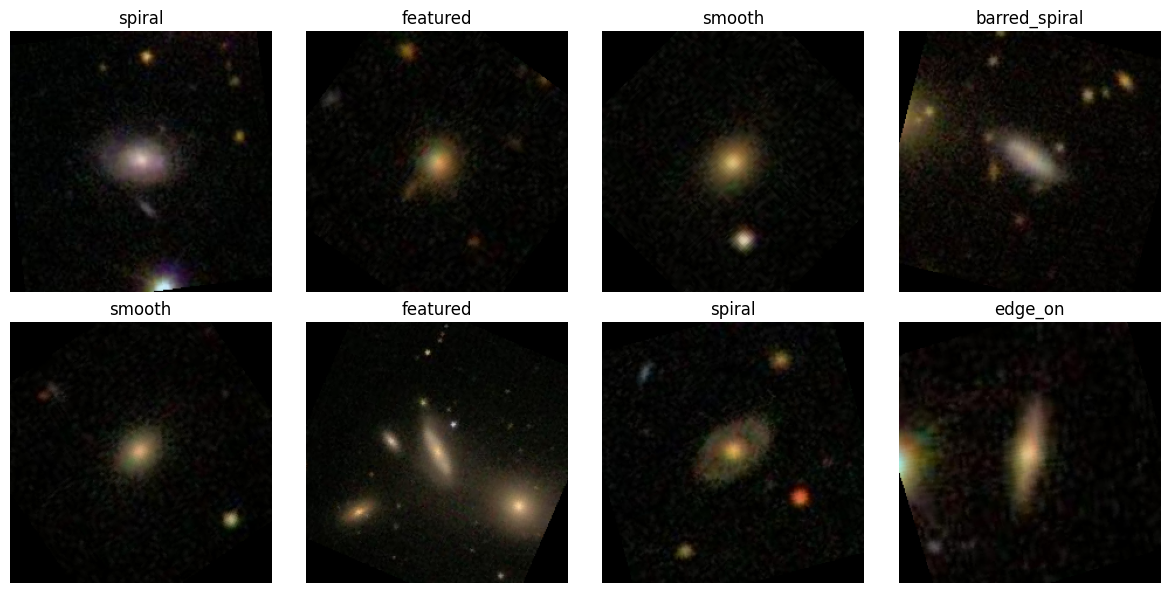

In [10]:
print(df.columns.tolist())
idx2label = {v: k for k, v in class_to_idx.items()}
imgs, labels = next(iter(train_loader))
print(imgs.shape)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = imgs[i].permute(1, 2, 0).numpy()
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(idx2label[labels[i].item()])
    ax.axis("off")
plt.tight_layout()
plt.show()